# RQ1: Effects on Mutation Score

**Research Question**: To which degree does generalization affect the mutation score of the target test suites?

This notebook analyzes mutation detection effectiveness across different Teralizer variants:
- **INITIAL**: Project state after instrumentation, test analysis, and specification extraction, but before any tests have been generalized
- **NAIVE**: Generalized tests with random input selection (200 tries)
- **IMPROVED**: Generalized tests with boundary-focused input selection (200 tries)

In [1]:
from teralizer.config import db_config
from teralizer.rq1_mutation_detection import (
    get_mutation_coverage_data,
    get_total_classes_from_filesystem,
    get_mutation_results_by_project_variant,
    get_mutation_results_by_mutator,
    get_mutation_detection_comparison,
    get_project_mutator_data,
    compute_project_mutation_coverage,
    compute_detection_improvements,
    compute_mutator_statistics,
    compute_mutation_model_complexity,
    generate_mutants_per_project_table,
    generate_mutants_per_project_csv,
    generate_mutation_detection_figure_csv,
    generate_detections_per_mutator_table,
    generate_detections_per_mutator_csv,
    generate_mutation_detection_comparison_table,
    generate_mutation_detection_comparison_csv,
)
from teralizer.exports import save_latex_table, save_csv_data, save_figure
from teralizer.plotting import setup_paper_style, FIGURE_CONFIG
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import re

# Database connection
conn = db_config.get_dev_engine()

# Configure paper style
setup_paper_style()

## Included Mutants

Establishes the evaluation baseline by showing what portion of the original projects are included in the analysis.

In [2]:
# Get mutation coverage data with test/class inclusion statistics
coverage_data = get_mutation_coverage_data(conn)
classes_data = get_total_classes_from_filesystem(conn)
coverage_stats = compute_project_mutation_coverage(coverage_data, classes_data)

# Generate LaTeX table and CSV data
mutants_table = generate_mutants_per_project_table(coverage_stats)
mutants_csv = generate_mutants_per_project_csv(coverage_stats)

# Save outputs
save_latex_table(mutants_table, "tab-mutants-per-project")
save_csv_data(mutants_csv, "mutants-per-project-data")

print(f"Generated table for {len(coverage_stats)} projects")
display(coverage_stats.head())

Projects directory not found. Loading pre-computed class counts...
Saved LaTeX table to /app/analysis/output/verify/tables/tab-mutants-per-project.tex
Generated table for 7 projects


,project_id,project,total,covered,uncovered,covered_pct,uncovered_pct,total_tests,included_tests,included_classes,total_classes
4,31,eqbench-es-default-1s,23905,21492,2413,89.91,10.09,4718,3937,607,652
5,34,eqbench-es-default-10s,23654,21657,1997,91.56,8.44,4875,4049,600,652
3,30,eqbench-es-default-60s,23663,22010,1653,93.01,6.99,4974,4124,603,652
2,25,commons-utils-es-default-1s,8581,7536,1045,87.82,12.18,2481,2079,111,247
6,36,commons-utils-es-default-10s,8391,7939,452,94.61,5.39,2738,2330,112,247


## Overall Mutation Detection Rates

Main visualization showing detection rates and improvements across all variants.

In [3]:
# Get mutation results for all variants and projects
mutation_results = get_mutation_results_by_project_variant(conn)
mutation_results = compute_detection_improvements(mutation_results)

# Generate CSV data for figures
figure_data = generate_mutation_detection_figure_csv(mutation_results)
save_csv_data(figure_data, "mutation-detection-figure-data")

print(f"Generated data for {len(mutation_results)} project-variant combinations")
display(
    mutation_results[
        ["project_name", "variant", "detected_of_covered_pct", "absolute_improvement"]
    ].head(10)
)

Generated data for 49 project-variant combinations


,project_name,variant,detected_of_covered_pct,absolute_improvement
0,commons-utils,INITIAL,80.35,0.00
1,commons-utils,NAIVE_10_TRIES,80.40,0.05
2,commons-utils,NAIVE_50_TRIES,80.42,0.07
3,commons-utils,NAIVE_200_TRIES,80.40,0.05
4,commons-utils,IMPROVED_10_TRIES,80.40,0.05
5,commons-utils,IMPROVED_50_TRIES,80.40,0.05
6,commons-utils,IMPROVED_200_TRIES,80.40,0.05
7,commons-utils-es-default-60s,INITIAL,58.12,0.00
8,commons-utils-es-default-60s,NAIVE_10_TRIES,59.13,1.01
9,commons-utils-es-default-60s,NAIVE_50_TRIES,59.09,0.97


Saved figure to /app/analysis/output/verify/figures/fig_mutation_detection_comparison.pdf


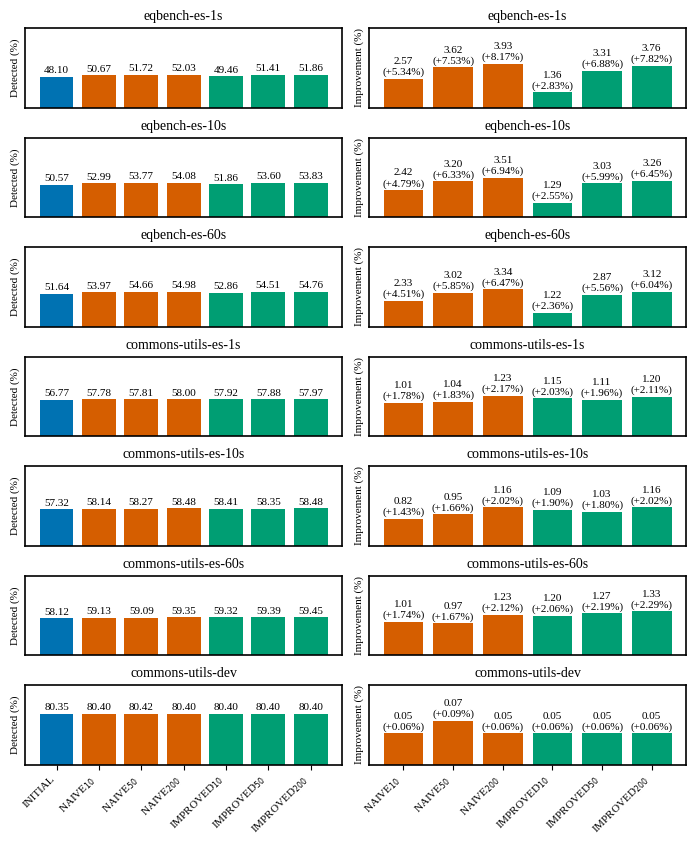

In [4]:
# Create mutation detection visualization
from matplotlib.axes import Axes
from teralizer.exports import (
    get_table_group_order,
    get_project_within_type_order,
    standardize_project_name,
)
from teralizer.plotting import (
    get_variant_color,
    get_wong_variant_colors,
    get_font_size,
    calculate_label_offset,
)
from typing import cast

# Get Wong colorblind-safe colors
wong_colors = get_wong_variant_colors()


def get_base_project(name):
    return re.sub(r"-\d+s$", "", name)


def format_variant_label(label):
    """Format variant labels for display."""
    match = re.match(r"([A-Z]+)_([0-9]+)_TRIES", label)
    if match:
        name, number = match.groups()
        return f"{name}$_{{{number}}}$"
    else:
        return label


# Add base project for grouping
mutation_results["base_project"] = mutation_results["project_name"].apply(
    get_base_project
)

# Sort projects by table order
project_within_type_order = get_project_within_type_order()
projects = mutation_results["project_name"].unique()
projects = sorted(
    projects,
    key=lambda p: (
        get_table_group_order(p, "INITIAL"),
        project_within_type_order.get(p, 99),
    ),
)

# Calculate improvement ranges for each base project
base_projects = sorted(
    mutation_results["base_project"].unique(),
    key=lambda p: (
        get_table_group_order(p, "INITIAL"),
        project_within_type_order.get(p, 99),
    ),
)

improvement_range = {}
for base in base_projects:
    max_improvement = 0
    for project in mutation_results[mutation_results["base_project"] == base][
        "project_name"
    ].unique():
        project_data = mutation_results[mutation_results["project_name"] == project]
        improvement_data = project_data[project_data["variant"] != "INITIAL"]
        if not improvement_data.empty:
            max_improvement = max(
                max_improvement, improvement_data["absolute_improvement"].max()
            )
    margin = 0.45 * abs(max_improvement)
    improvement_range[base] = (0, max_improvement + margin)

# Create figure with standardized dimensions
n_projects = len(projects)
fig_width = FIGURE_CONFIG["width_multibar"]
fig_height = FIGURE_CONFIG["max_height"]
fig, axes = plt.subplots(n_projects, 2, figsize=(fig_width, fig_height), squeeze=False)

for i, project in enumerate(projects):
    project_data = mutation_results[mutation_results["project_name"] == project].copy()
    variants = project_data["variant"].tolist()
    x_positions = np.arange(len(variants))

    bar_colors_left = [get_variant_color(v) for v in variants]

    # Left plot: Detection rates (all variants)
    ax_left = cast(Axes, axes[i, 0])
    ax_right = cast(Axes, axes[i, 1])

    bars_left = ax_left.bar(
        x_positions, project_data["detected_of_covered_pct"], color=bar_colors_left
    )
    ax_left.set_title(standardize_project_name(project))
    ax_left.set_ylabel("Detected (%)")

    # Set y-axis with padding to prevent label overflow
    y_max_left = 100 * FIGURE_CONFIG["y_padding_multiplier"]
    ax_left.set_ylim(0, y_max_left)

    # Add value labels on left plot with percentage-based offset
    offset_left = calculate_label_offset(
        0, y_max_left, FIGURE_CONFIG["label_offset_pct"]
    )
    for bar in bars_left:
        height = bar.get_height()
        ax_left.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset_left,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=get_font_size("small"),
        )

    # Right plot: Improvement over INITIAL
    improvement_data = project_data[project_data["variant"] != "INITIAL"].copy()
    improvement_variants = improvement_data["variant"].tolist()
    x_positions_imp = np.arange(len(improvement_variants))

    if not improvement_data.empty:
        initial_row = project_data[project_data["variant"] == "INITIAL"]
        initial_detected = (
            initial_row["detected_of_covered_pct"].iloc[0]
            if not initial_row.empty
            else 0
        )
        improvements = improvement_data["absolute_improvement"].tolist()
    else:
        improvements = [0] * len(improvement_variants)

    bar_colors_right = [get_variant_color(v) for v in improvement_variants]

    bars_right = ax_right.bar(x_positions_imp, improvements, color=bar_colors_right)
    ax_right.axhline(0, color="gray", linewidth=0.8)
    ax_right.set_title(standardize_project_name(project))
    ax_right.set_ylabel("Improvement (%)")

    # Set y-axis limits based on calculated range with padding
    base_project = get_base_project(project)
    y_min, y_max = improvement_range[base_project]
    y_max_padded = y_max * FIGURE_CONFIG["y_padding_multiplier"]
    ax_right.set_ylim(y_min, y_max_padded)

    # Add improvement labels with percentage-based offset
    offset_right = calculate_label_offset(
        y_min, y_max_padded, FIGURE_CONFIG["label_offset_pct"]
    )
    for j, bar in enumerate(bars_right):
        height = bar.get_height()
        if not improvement_data.empty and not initial_row.empty:
            rel_imp = improvement_data.iloc[j]["relative_improvement"]
            label = f"{height:.2f}\n({rel_imp:+.2f}%)"
        else:
            label = f"{height:.2f}\n(+0.0%)"

        if height >= 0:
            va = "bottom"
            text_offset = offset_right
        else:
            va = "top"
            text_offset = -offset_right

        ax_right.text(
            bar.get_x() + bar.get_width() / 2,
            height + text_offset,
            label,
            ha="center",
            va=va,
            fontsize=get_font_size("small"),
        )

    # Set x-axis labels only for bottom subplot
    if i == n_projects - 1:
        ax_left.set_xticks(x_positions)
        ax_left.set_xticklabels(
            [format_variant_label(v) for v in variants], rotation=45, ha="right"
        )
        ax_right.set_xticks(x_positions_imp)
        ax_right.set_xticklabels(
            [format_variant_label(v) for v in improvement_variants],
            rotation=45,
            ha="right",
        )
    else:
        ax_left.set_xticks([])
        ax_right.set_xticks([])

    ax_left.set_yticks([])
    ax_right.set_yticks([])

# Add legend
# legend_elements = [
#     Patch(facecolor=wong_colors["INITIAL"], label="INITIAL"),
#     Patch(facecolor=wong_colors["NAIVE_10_TRIES"], label="NAIVE"),
#     Patch(facecolor=wong_colors["IMPROVED_10_TRIES"], label="IMPROVED"),
# ]
# fig.legend(
#     handles=legend_elements,
#     loc="upper center",
#     ncol=3,
#     bbox_to_anchor=(0.5, 1.03),
#     frameon=False,
# )

plt.tight_layout()
save_figure(fig, "fig_mutation_detection_comparison")
plt.show()

## Mutation Detection Rates per Mutator

Detailed breakdown by mutation operator type to analyze which mutations benefit most from generalization.

In [5]:
# Get mutator-specific detection data
variant_data = get_mutation_results_by_mutator(
    conn,
    [
        "INITIAL",
        "NAIVE_10_TRIES",
        "NAIVE_50_TRIES",
        "NAIVE_200_TRIES",
        "IMPROVED_10_TRIES",
        "IMPROVED_50_TRIES",
        "IMPROVED_200_TRIES",
    ],
)
project_data = get_project_mutator_data(conn)
mutator_stats = compute_mutator_statistics(variant_data, project_data)

# Generate LaTeX table and CSV data
detections_table = generate_detections_per_mutator_table(mutator_stats)
detections_csv = generate_detections_per_mutator_csv(mutator_stats)

# Save outputs
save_latex_table(detections_table, "tab-detections-per-mutator")
save_csv_data(detections_csv, "detections-per-mutator-data")

print(f"Generated mutator analysis for {len(mutator_stats)} mutator types")
display(
    mutator_stats[
        [
            "mutator",
            "total_mutants",
            "percent",
            "INITIAL",
            "NAIVE_200_TRIES",
            "IMPROVED_200_TRIES",
        ]
    ].head()
)

Saved LaTeX table to /app/analysis/output/verify/tables/tab-detections-per-mutator.tex
Generated mutator analysis for 12 mutator types


,mutator,total_mutants,percent,INITIAL,NAIVE_200_TRIES,IMPROVED_200_TRIES
0,MathMutator,61841.0,59.096556,50.989163,54.982556,54.362440
4,ConditionalsBoundaryMutator,11501.0,10.990597,27.682010,28.892353,30.231065
3,RemoveConditionalMutator_ORDER_ELSE,11501.0,10.990597,61.076472,62.286815,62.470200
6,PrimitiveReturnsMutator,7731.0,7.387906,89.424224,89.628967,89.898689
10,RemoveConditionalMutator_EQUAL_ELSE,5536.0,5.290318,58.802608,60.868707,60.998225


## Effectiveness of IMPROVED Boundary Detection

Model complexity analysis explaining why IMPROVED variants perform better/worse than NAIVE variants.

In [6]:
# Get model complexity comparison data
comparison_data = get_mutation_detection_comparison(conn)
complexity_stats = compute_mutation_model_complexity(comparison_data)

# Generate LaTeX table and CSV data
comparison_table = generate_mutation_detection_comparison_table(complexity_stats)
comparison_csv = generate_mutation_detection_comparison_csv(complexity_stats)

# Save outputs
save_latex_table(comparison_table, "tab-mutation-detection-comparison")
save_csv_data(comparison_csv, "mutation-detection-comparison-data")

print(
    f"Generated complexity comparison for {len(complexity_stats)} project-detection combinations"
)
display(
    complexity_stats[
        [
            "project_name",
            "is_detected",
            "count",
            "avg_model_operation_count",
            "avg_total_constraint_count",
            "avg_used_constraint_pct",
        ]
    ].head()
)

Saved LaTeX table to /app/analysis/output/verify/tables/tab-mutation-detection-comparison.tex
Generated complexity comparison for 14 project-detection combinations


,project_name,is_detected,count,avg_model_operation_count,avg_total_constraint_count,avg_used_constraint_pct
8,eqbench-es-default-1s,yes,11145,147.128600,6.096047,47.047823
9,eqbench-es-default-1s,no,10347,224.828735,11.561005,23.563487
10,eqbench-es-default-10s,yes,11658,139.129308,6.199408,62.130599
11,eqbench-es-default-10s,no,9999,231.441957,8.287730,57.529617
6,eqbench-es-default-60s,yes,12052,137.699642,5.500165,69.985969


## RQ1 Analysis Complete

Generated outputs:
- `tab-mutants-per-project.tex` - Mutation coverage baseline
- `mutants-per-project-data.csv` - Mutation coverage data
- `mutation-detection-figure-data.csv` - Detection rate visualization data
- `fig_mutation_detection_comparison.pdf` - Overall detection rate visualization
- `tab-detections-per-mutator.tex` - Detection rates by mutator type
- `detections-per-mutator-data.csv` - Detection rates data by mutator type
- `tab-mutation-detection-comparison.tex` - Model complexity analysis
- `mutation-detection-comparison-data.csv` - Model complexity comparison data